# SDA 2026: Final project

## Introduction

The distribution of exoplanet radii shows a deficit of planets with radii around $\sim$1.5-2 $R_\oplus$, commonly referred to as the *radius valley*. This feature is thought to reflect the physical processes that shape planetary atmospheres, such as photoevaporation or core-powered mass loss.

In this assignment, you will analyze a catalog of confirmed exoplanets to investigate the radius valley. You will use a combination of kernel density estimation (KDE), bootstrapping, and maximum likelihood estimation.

## Objective and output

The goal of this assignment is to measure the location of the radius valley and to quantify its dependence on orbital period. The radius valley is treated as a linear model in log-log space of radius and period:

$$\log{R_\mathrm{valley}} = a + b\log{P}$$

**Tasks** 

You are expected to:
- Identify the radius valley in the planet sample using a KDE.
- Divide the data set into period bins and estimate the valley location in each bin.
- Quantify uncertainties on the valley location using bootstrap resampling.
- Fit the linear model in log-log space using maximum likelihood estimation.
- Calculate a likelihood map for parameters $a$ and $b$ and determine confidence intervals.
- Test whether the likelihood favors a model with a non-zero slope.

**Required outputs**

Your results should include (at least):
- A period-radius diagram (log-log scale) showing:
   - the full planet sample,
   - the estimated valley locations in each period bin (with uncertainties),
   - the best-fit model and the confidence region.
- A 2D likelihood map in the $(a,b)$ parameter space.
- A comparison of the maximum likelihood of $b = 0$ with $b \neq 0$

## Intermediate steps

Follow the steps below and clearly document them in your code.

1. Select planets with:
    - orbital periods between 1 and 50 days,
    - radii between 1 and 4 $R_\oplus$,
    - relative radius uncertainties better than 20%.
2. Define 4 log-spaced period bins between 1 and 10 days.
3. Create a period-radius scatter plot in log–log space.
   Overplot a linear relation on the approximate radius valley, to obtain intuition for the parameters $a$ and $b$.
4. Plot the distribution of $\log R$ and compute a Gaussian KDE.
   Explore how the KDE depends on the bandwidth.
5. Test the `find_kde_valley` function to verify that it correctly identifies the radius valley in each period bin.
6. Perform bootstrap resampling:
    - draw radii from their measurement uncertainties,
    - recompute the valley location for each bootstrap sample,
    - calculate the median and 68% confidence interval of the radius valley for each period bin.
7. Define a log-likelihood function for the linear model.
   Evaluate it on a grid in $(a, b)$ and determine the maximum likelihood solution.
   Plot 1, 3, and 5$\sigma$ confidence contours on the likelihood map.
8. Compare the maximum likelihood values for the models with $b = 0$ and $b \neq 0$.

## Submitting formats

You must submit:
- A written report (see assessment criteria on Brightspace).
- A single Python script (.py) that reproduces all figures and calculations.

You may use functionalities from NumPy, SciPy, Matplotlib, Astropy, and Pandas.

## Imports and general settings

In [30]:
import matplotlib.pyplot as plt
import numpy as np

In [31]:
from astropy.io import ascii
from scipy.signal import find_peaks
from scipy import stats
from scipy import optimize

In [32]:
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["xtick.minor.visible"] = True
plt.rcParams["ytick.minor.visible"] = True

## Function for finding the radius valley

In [33]:
def find_kde_valley(logR_sample, bw_method=None):
    """
    Find the radius valley between the two peaks in the PDF
    of log(radius) using a Gaussian KDE. The function selects
    the valley between the two most prominent peaks.
    
    The result is sensitive to ``bw_method``. You are encouraged
    to experiment with both the KDE bandwidth and the parameters
    of ``find_peaks``.

    Parameters
    ----------
    logR_sample : np.ndarray
        Array with log(radius) samples.
    bw_method : float
        Bandwidth for the KDE.

    Returns
    -------
    float, None
        The radius valley, as log(R_valley). Returns None if fewer
        than two peaks are found or no valid valley exists.
    np.ndarray
        The grid of log(R_valley) values over which the KDE was evaluated.
    np.ndarray
        The KDE for the grid of log(R_valley) values.
    """

    kde = stats.gaussian_kde(logR_sample, bw_method=bw_method)

    logr_grid = np.linspace(np.min(logR_sample), np.max(logR_sample), 200)
    pdf = kde(logr_grid)

    peaks, props = find_peaks(pdf, prominence=0.01*np.max(pdf))
    valleys, _ = find_peaks(-pdf)

    log_radius_valley = None
    
    if len(peaks) >= 2:
        top_two = peaks[np.argsort(pdf[peaks])[-2:]]
        top_two = np.sort(top_two)

        valley_candidates = valleys[
            (logr_grid[valleys] > logr_grid[top_two[0]]) &
            (logr_grid[valleys] < logr_grid[top_two[1]])
        ]

        if len(valley_candidates) > 0:
            valley_idx = valley_candidates[np.argmin(pdf[valley_candidates])]
            log_radius_valley = logr_grid[valley_idx], 

    return log_radius_valley, logr_grid, pdf

In [34]:
# 1. Data extraction
from tarfile import data_filter


data = ascii.read("exoplanet_data.csv") # imports the dataset

# 2. Data filtering
print(f'Before filtering: {len(data)} planets')
mask = (data['P'] < 50) & (data['P'] > 1) & (data['Rplanet'] < 4) & (data['Rplanet'] > 1) & (data['Rplanet_sigma'] / data['Rplanet'] < 0.2)
data_filtered = data[mask]
print(f'After filtering: {len(data_filtered)} planets')

Before filtering: 4676 planets
After filtering: 2529 planets


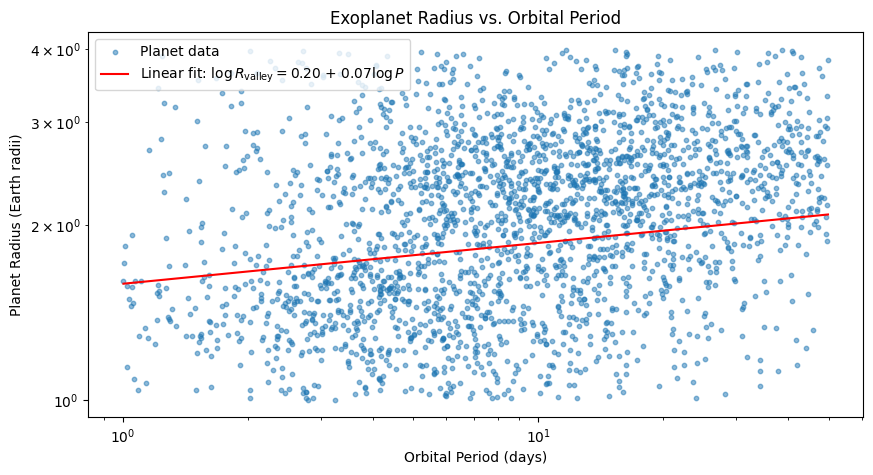

In [35]:
# 3. Creating bins
bins = np.logspace(0, 1, 4) # creates 4 logarithmically spaced bins between 1 and 10

# 4. Scatter plot
plt.loglog()
plt.scatter(data_filtered['P'], data_filtered['Rplanet'], s=10, alpha=0.5, label='Planet data')
# plt.errorbar(data_filtered['P'], data_filtered['Rplanet'], yerr=data_filtered['Rplanet_sigma'], fmt='o', markersize=3, alpha=0.1, label='Planet data')


x_fit = np.linspace(np.min(data_filtered['P']), np.max(data_filtered['P']), 1000)
a, b = 0.2, 0.07
y_fit = 10**a * x_fit**b
plt.plot(x_fit, y_fit, color='red', label='Linear fit: ' + r'$\log R_\text{valley} = $' + f'{a:.2f} + {b:.2f}' + r'$\log P$')

plt.xlabel('Orbital Period (days)')
plt.ylabel('Planet Radius (Earth radii)')
plt.title('Exoplanet Radius vs. Orbital Period')
plt.legend()
plt.show()

for bandwidth 0.1, log(R_valley) = 1.81 Earth radii
for bandwidth 0.2, log(R_valley) = 1.79 Earth radii


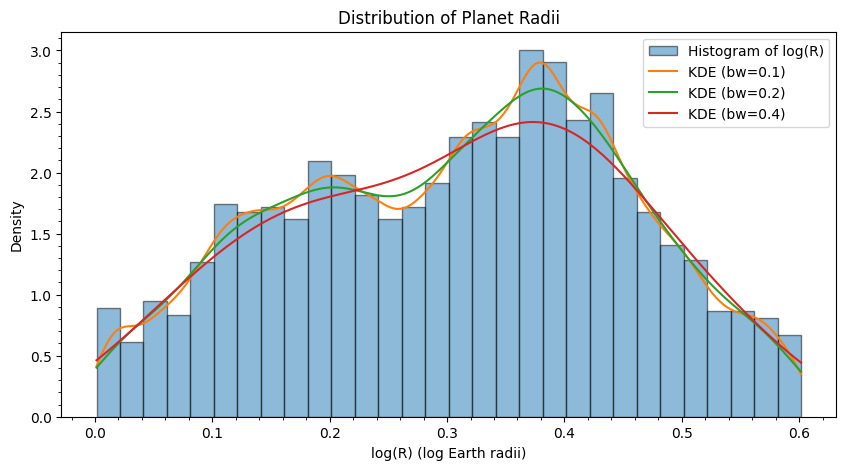

In [36]:
# 5. R distribution and KDE
from math import log


logR_sample = np.log10(data_filtered['Rplanet'])
plt.hist(logR_sample, bins=30, density=True, alpha=0.5, label='Histogram of log(R)', edgecolor='black')
for bw in [0.1, 0.2, 0.4]:
    logR_valley, logr_grid, pdf = find_kde_valley(logR_sample, bw_method=bw)
    if logR_valley is not None:
        print(f'for bandwidth {bw}, log(R_valley) = {10**logR_valley[0]:.2f} Earth radii')
    plt.plot(logr_grid, pdf, label=f'KDE (bw={bw})')
plt.xlabel('log(R) (log Earth radii)')
plt.ylabel('Density')
plt.title('Distribution of Planet Radii')
plt.legend()
plt.show()

<>:46: SyntaxWarning: invalid escape sequence '\o'
<>:47: SyntaxWarning: invalid escape sequence '\o'
<>:48: SyntaxWarning: invalid escape sequence '\o'
<>:46: SyntaxWarning: invalid escape sequence '\o'
<>:47: SyntaxWarning: invalid escape sequence '\o'
<>:48: SyntaxWarning: invalid escape sequence '\o'
C:\Users\mikov\AppData\Local\Temp\ipykernel_2000\4097842474.py:46: SyntaxWarning: invalid escape sequence '\o'
  plt.axvline(p16, color='red', linestyle='--', label=f'16th percentile: {10**p16:.2f} $R_\oplus$')
C:\Users\mikov\AppData\Local\Temp\ipykernel_2000\4097842474.py:47: SyntaxWarning: invalid escape sequence '\o'
  plt.axvline(median, color='blue', linestyle='-', label=f'Median: {10**median:.2f} $R_\oplus$')
C:\Users\mikov\AppData\Local\Temp\ipykernel_2000\4097842474.py:48: SyntaxWarning: invalid escape sequence '\o'
  plt.axvline(p84, color='red', linestyle='--', label=f'84th percentile: {10**p84:.2f} $R_\oplus$')


Bin 1: 1.00 - 1.78 days, 88 planets


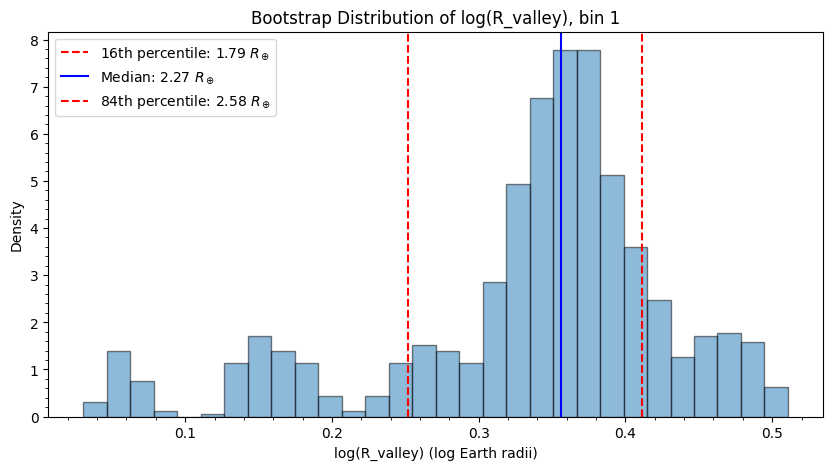

Bin 2: 1.78 - 3.16 days, 229 planets


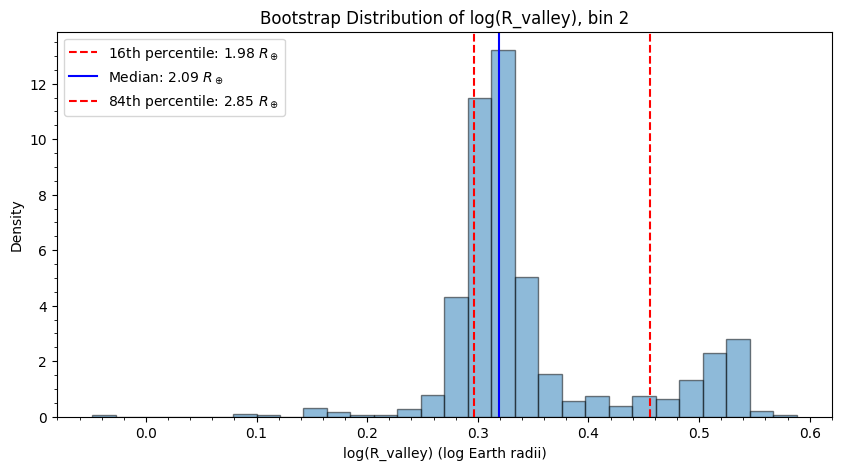

Bin 3: 3.16 - 5.62 days, 447 planets


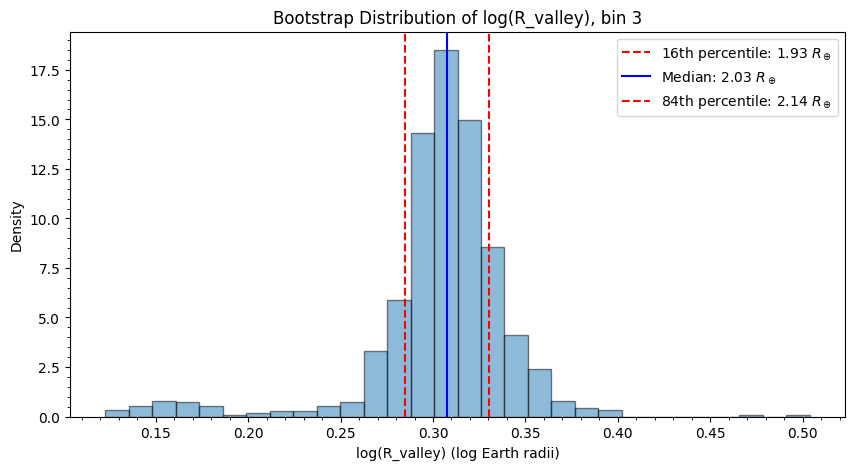

Bin 4: 5.62 - 10.00 days, 589 planets


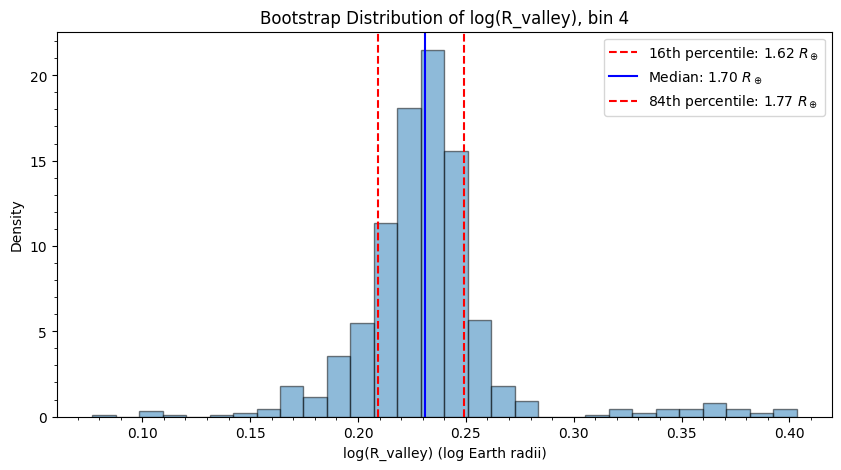

In [ ]:
# 6. Bootstrap resampling per period bin
period_bins = np.logspace(0, 1, 5)  # 4 log-spaced bins between 1 and 10 days

bootstrap_results = []

for bin_index in range(len(period_bins) - 1):
    p_bounds = period_bins[bin_index: bin_index + 2]

    bin_mask = (data_filtered['P'] >= p_bounds[0]) & (data_filtered['P'] < p_bounds[1])
    bin_data = data_filtered[bin_mask]

    print(f'Bin {bin_index + 1}: {p_bounds[0]:.2f} - {p_bounds[1]:.2f} days, {len(bin_data)} planets')

    bin_bootstrap_valleys = []

    for i in range(1000):
        sample_indices = np.random.randint(0, len(bin_data), len(bin_data))
        sampled_radii = np.asarray(bin_data['Rplanet'])[sample_indices]
        sampled_sigma = np.asarray(bin_data['Rplanet_sigma'])[sample_indices]

        rng_radii = np.random.normal(loc=sampled_radii, scale=sampled_sigma)
        rng_radii = rng_radii[rng_radii > 0]

        logR_bootstrap = np.log10(rng_radii)
        logR_valley, grid, KDE_vals = find_kde_valley(logR_bootstrap, bw_method=0.2)

        if logR_valley is not None:
            bin_bootstrap_valleys.append(logR_valley[0])

    bin_bootstrap_valleys = np.asarray(bin_bootstrap_valleys)

    median = np.median(bin_bootstrap_valleys)
    p16, p84 = np.percentile(bin_bootstrap_valleys, [16, 84])

    bootstrap_results.append({
        'bin': bin_index + 1,
        'period_range': (p_bounds[0], p_bounds[1]),
        'valleys': bin_bootstrap_valleys,
        'median': median,
        'p16': p16,
        'p84': p84,
    })

    plt.hist(bin_bootstrap_valleys, bins=30, density=True, alpha=0.5, edgecolor='black')
    plt.axvline(p16, color='red', linestyle='--', label=f'16th percentile: {10**p16:.2f} $R_\oplus$')
    plt.axvline(median, color='blue', linestyle='-', label=f'Median: {10**median:.2f} $R_\oplus$')
    plt.axvline(p84, color='red', linestyle='--', label=f'84th percentile: {10**p84:.2f} $R_\oplus$')
    plt.xlabel('log(R_valley) (log Earth radii)')
    plt.ylabel('Density')
    plt.title(f'Bootstrap Distribution of log(R_valley), bin {bin_index + 1}')
    plt.legend()
    plt.show()


In [ ]:
# log-likelihood function for linear model
def log_likelihood(a, b, logP, logR_valley, sigma):
    model = a + b * logP
    residuals = logR_valley - model
    return -0.5 * np.sum((residuals / sigma) ** 2)



0.4338146514707051 -0.21934338014883487


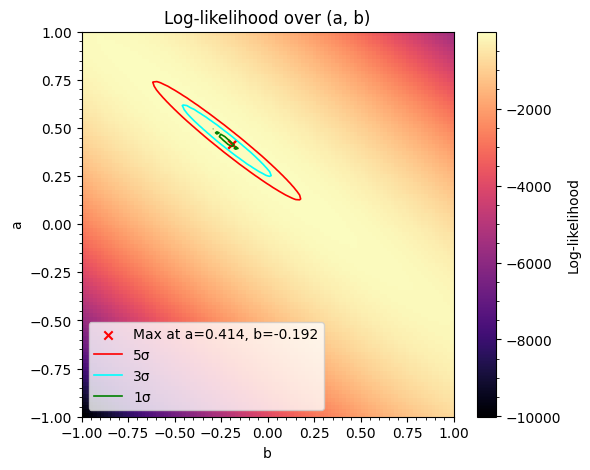

In [78]:
# Build a grid of (a,b) and evaluate the log-likelihood for each pair
# Uses the previously computed `bootstrap_results` and `log_likelihood`.

a_vals, b_vals = np.linspace(-1, 1, 100), np.linspace(-1, 1, 100)

# extract the per-bin values computed from bootstrap_results
logP = np.log10([np.mean(r['period_range']) for r in bootstrap_results])
logR = np.array([r['median'] for r in bootstrap_results])
sigma = np.array([(r['p84'] - r['p16']) / 2 for r in bootstrap_results])

L = np.empty((len(a_vals), len(b_vals)))

for i, a_ in enumerate(a_vals):
    for j, b_ in enumerate(b_vals):
        L[i, j] = log_likelihood(a_, b_, logP=logP, logR_valley=logR, sigma=sigma)

# Plot heatmap with imshow (a on y-axis, b on x-axis)
plt.figure(figsize=(6,5))
plt.imshow(L, origin='lower', extent=[b_vals[0], b_vals[-1], a_vals[0], a_vals[-1]], aspect='auto', cmap='magma')
plt.xlabel('b')
plt.ylabel('a')
plt.title('Log-likelihood over (a, b)')
plt.colorbar(label='Log-likelihood')

# Mark maximum-likelihood location
imax = np.unravel_index(np.argmax(L), L.shape)
best_a = a_vals[imax[0]]
best_b = b_vals[imax[1]]
plt.scatter(best_b, best_a, color='red', marker='x', label=f'Max at a={best_a:.3f}, b={best_b:.3f}')

# --- Added: posterior-mass based contour levels (enclose 1,3,5-sigma mass fractions) ---
ks = np.array([1.0, 3.0, 5.0])
target_probs = 1.0 - np.exp(-0.5 * ks ** 2)

L_flat = L.ravel()
post_unnorm = np.exp(L_flat - L_flat.max())
post_norm = post_unnorm / post_unnorm.sum()

sort_idx = np.argsort(-post_norm)
sorted_post = post_norm[sort_idx]
sorted_L = L_flat[sort_idx]
cumsum = np.cumsum(sorted_post)

levels = []
for p in target_probs:
    idx = np.searchsorted(cumsum, p)
    if idx >= len(sorted_L):
        lvl = sorted_L[-1]
    else:
        lvl = sorted_L[idx]
    levels.append(lvl)

# Ensure levels are in ascending order for contour and create matching labels
levels = np.array(levels)
labels = [f'{int(k)}\u03C3' for k in ks]
order = np.argsort(levels)
levels_sorted = levels[order]
labels_sorted = [labels[i] for i in order]

colors_contour = ['red', 'cyan', 'green']
B, A = np.meshgrid(b_vals, a_vals)
cs = plt.contour(B, A, L, levels=levels_sorted, colors=colors_contour, linewidths=1.2)

# Add contours to legend
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], color=colors_contour[i], linewidth=1.2, label=labels_sorted[i]) 
                   for i in range(len(levels_sorted))]
plt.legend(loc='lower left', handles=[plt.scatter(best_b, best_a, color='red', marker='x', label=f'Max at a={best_a:.3f}, b={best_b:.3f}')] + legend_elements)
# --- end added contours ---

plt.show()

In [80]:
# max likelihood b=0
max_likelihood_b0 = log_likelihood(a=best_a, b=0, logP=logP, logR_valley=logR, sigma=sigma)
print(f'Max likelihood at b=0: {max_likelihood_b0:.3f}')
max_likelihood = log_likelihood(a=best_a, b=best_b, logP=logP, logR_valley=logR, sigma=sigma)
print(f'Max likelihood at best fit: {max_likelihood:.3f}')
likelihood_ratio = np.exp(max_likelihood_b0 - max_likelihood)
print(f'Likelihood ratio (b=0 vs best fit): {likelihood_ratio:.3e}')
print('The likelihood ratio is much smaller than 1, close to 0. Meaning that the likelihood favors a model with a non zero slope.')

Max likelihood at b=0: -56.234
Max likelihood at best fit: -0.563
Likelihood ratio (b=0 vs best fit): 6.644e-25
The likelihood ratio is much smaller than 1, close to 0. Meaning that the likelihood favors a model with a non zero slope.
